# Apprentissage supervisé — Prédiction de la puissance nominale d'une borne

## Présentation du problème

On dispose d'une base de bornes de recharge décrites par plusieurs caractéristiques (nombre de points de charge, types de prises, lieu d'implantation, etc.). **Objectif : construire un modèle d'intelligence artificielle capable de prédire la puissance nominale d'une borne** à partir de ces caractéristiques.

Il s'agit d'un problème d'**apprentissage supervisé** : on apprend à partir d'exemples dont on connaît déjà la réponse (la puissance), puis on généralise à de nouvelles bornes.

La puissance prend 192 valeurs différentes dans la base. Prédire une valeur exacte parmi 192 serait très difficile et peu utile. On choisit donc de **regrouper la puissance en 4 catégories de recharge** (lente, accélérée, rapide, ultra-rapide) et de faire de la **classification** : le modèle prédit la catégorie de la borne.

## Plan du notebook
1. Chargement des données
2. Construction de la cible (les 4 classes de puissance)
3. Choix et justification des variables
4. Prétraitement (encodage + normalisation)
5. Séparation train / test
6. **Comparaison de plusieurs modèles** et choix du meilleur
7. Optimisation des hyperparamètres avec GridSearchCV
8. Évaluation détaillée (métriques, matrice de confusion, importances)
9. Sauvegarde du modèle (avec le prétraitement)
10. Script de prédiction

## 1. Chargement des données

On monte Google Drive (où se trouve le fichier) puis on lit le CSV. L'option `sep=None` laisse pandas détecter automatiquement le séparateur. On affiche les premières lignes pour vérifier que tout est bien chargé.

In [28]:
from google.colab import drive
drive.mount("/content/drive/")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('/content/drive/MyDrive/Projet_IA/exportIA.csv', sep=None, engine='python')
print("Dimensions du jeu de données :", df.shape)
df.head()

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
Dimensions du jeu de données : (141415, 53)


,Unnamed: 0,nom_amenageur,siren_amenageur,contact_amenageur,nom_operateur,contact_operateur,telephone_operateur,nom_enseigne,id_station_itinerance,id_station_local,...,datagouv_resource_id,datagouv_organization_or_owner,created_at,long,lat,consolidated_code_postal,consolidated_commune,consolidated_is_lon_lat_correct,consolidated_is_code_insee_verified,consolidated_is_code_insee_modified
0,1,syndicat mixte d'electricite de la guadeloupe ...,200010759.0,ep-energie@symeg.net,g-mob,contact@gmob.fr,+590590325142,gmob,frgobpies2024111385490003,ies2024111385490003,...,df592154-7616-4c01-9d89-6521e0011467,g-mob,2025-10-06t16:44:59.145000+00:00,-61.572327,16.237882,97122.0,baie-mahault,True,True,False
1,2,syndicat mixte d'electricite de la guadeloupe ...,200010759.0,ep-energie@symeg.net,g-mob,contact@gmob.fr,+590590325142,gmob,frgobpies2024111385490003,ies2024111385490003,...,df592154-7616-4c01-9d89-6521e0011467,g-mob,2025-10-06t16:44:59.145000+00:00,-61.572327,16.237882,97122.0,baie-mahault,True,True,False
2,3,syndicat mixte d'electricite de la guadeloupe ...,200010759.0,ep-energie@symeg.net,g-mob,contact@gmob.fr,+590590325142,gmob,frgobpies2024111385490004,ies2024111385490004,...,df592154-7616-4c01-9d89-6521e0011467,g-mob,2025-10-06t16:44:59.145000+00:00,-61.636493,16.271696,97129.0,lamentin,True,True,False
3,4,syndicat mixte d'electricite de la guadeloupe ...,200010759.0,ep-energie@symeg.net,g-mob,contact@gmob.fr,+590590325142,gmob,frgobpies2024111385490004,ies2024111385490004,...,df592154-7616-4c01-9d89-6521e0011467,g-mob,2025-10-06t16:44:59.145000+00:00,-61.636493,16.271696,97129.0,lamentin,True,True,False
4,5,zetra distribution,895193019.0,contact@zetra.com,zetra distribution sas,contact@zetra.com,0170946050,zetra,frzetpmeura,NaN,...,fe8d0b39-4814-4bf1-9601-16e1dea20fa8,zetra-distribution,2025-06-17t15:36:54.011000+00:00,4.799711,48.967183,21190.0,tailly,False,True,False


## 2. Construction de la cible : les classes de puissance

### Pourquoi transformer la cible ?
`puissance_nominale` est une grandeur **continue** avec 192 valeurs distinctes (7.4, 22, 50, 150...). On ne peut pas faire une classification avec 192 classes (beaucoup auraient trop peu d'exemples). On **regroupe** donc les puissances en 4 grandes familles, qui correspondent aux types de recharge réels du marché :

| Classe | Puissance | Type de recharge |
|---|---|---|
| `1_lente` | ≤ 7.4 kW | recharge lente (prise domestique renforcée) |
| `2_acceleree` | 7.4 – 22 kW | recharge accélérée (bornes urbaines) |
| `3_rapide` | 22 – 50 kW | recharge rapide |
| `4_ultra_rapide` | > 50 kW | recharge ultra-rapide en courant continu (autoroutes) |

### Nettoyage des valeurs aberrantes
Certaines lignes ont une puissance de 0 (donnée manquante) ou supérieure à 400 kW (erreurs de saisie, souvent en watts au lieu de kilowatts). On les retire pour ne pas fausser l'apprentissage.

classe_puissance
2_acceleree       62715
4_ultra_rapide    32198
1_lente           27495
3_rapide          18971
Name: count, dtype: int64


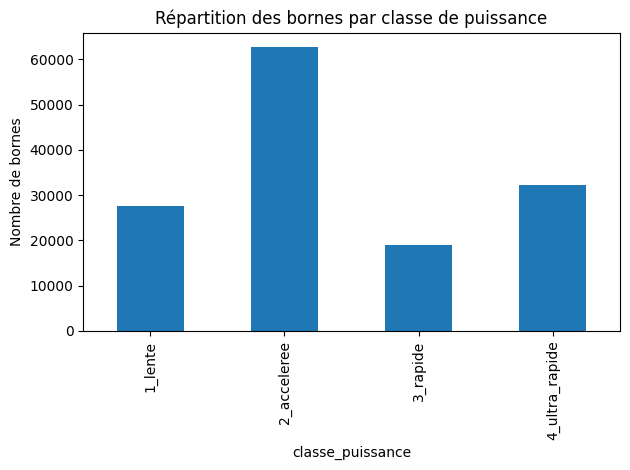

In [29]:
# On retire les puissances aberrantes (<= 0 ou > 400 kW)
df = df[(df['puissance_nominale'] > 0) & (df['puissance_nominale'] <= 400)].copy()

# Fonction qui transforme une puissance (kW) en classe
def classe_puissance(p):
    if p <= 7.4:
        return '1_lente'
    elif p <= 22:
        return '2_acceleree'
    elif p <= 50:
        return '3_rapide'
    else:
        return '4_ultra_rapide'

df['classe_puissance'] = df['puissance_nominale'].apply(classe_puissance)

# On regarde la répartition des classes
print(df['classe_puissance'].value_counts())
df['classe_puissance'].value_counts().sort_index().plot.bar(
    title="Répartition des bornes par classe de puissance")
plt.ylabel("Nombre de bornes")
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Projet_IA/classes_puiss.png')
plt.show()

**Lecture du graphe :** les 4 classes sont présentes en quantité suffisante (la plus rare représente quand même ~13 % des données). Le jeu est un peu **déséquilibré** (la classe « accélérée » domine) : on en tiendra compte au moment de choisir les métriques (on privilégiera le **F1-macro**, qui traite toutes les classes à égalité, plutôt que la simple accuracy).

## 3. Choix et justification des variables

On ne garde que les colonnes utiles pour expliquer la puissance, et on écarte celles qui sont inexploitables.

### Variables retenues
| Variable | Type | Pourquoi |
|---|---|---|
| `nbre_pdc` | numérique | une grosse station a souvent une puissance plus élevée |
| `prise_type_ef` | booléen | prise domestique → recharge lente |
| `prise_type_2` | booléen | prise Type 2 → recharge accélérée |
| `prise_type_combo_ccs` | booléen | **Combo CCS → recharge rapide DC** (très prédictif) |
| `prise_type_chademo` | booléen | **CHAdeMO → recharge rapide DC** (très prédictif) |
| `prise_type_autre` | booléen | autres prises |
| `implantation_station` | catégoriel | autoroute vs voirie n'ont pas la même puissance |
| `condition_acces` | catégoriel | accès libre / réservé |
| `gratuit` | booléen | les bornes gratuites sont souvent moins puissantes |
| `station_deux_roues` | booléen | recharge généralement faible |
| `consolidated_longitude` / `latitude` | numérique | effet géographique éventuel |

### Variables écartées
- **`tarification`** : 476 valeurs en texte libre (« 0,38 €/kWh », « 0 », ...), non exploitable sans gros nettoyage.
- **`horaires`** : formats très hétérogènes, peu lié à la puissance.
- **`puissance_nominale`** : c'est la **cible**, elle ne doit JAMAIS servir de variable d'entrée (sinon le modèle « triche »).

### Nettoyage des booléens
Les colonnes booléennes contiennent des valeurs incohérentes (`true`, `True`, `TRUE`, `false`...). On les transforme en 0/1 : `true` (ou `vrai`) devient 1, tout le reste devient 0. On fera la même conversion dans le script final.

In [30]:
num_features  = ['nbre_pdc', 'long', 'lat']
bool_features = ['prise_type_ef', 'prise_type_2', 'prise_type_combo_ccs',
                 'prise_type_chademo', 'prise_type_autre', 'gratuit', 'station_deux_roues']
cat_features  = ['implantation_station', 'condition_acces']

# On transforme les booléens en 0/1 (true -> 1, le reste -> 0)
for col in bool_features:
    df[col] = df[col].astype(str).str.lower().isin(['true', 'vrai']).astype(int)

features = num_features + bool_features + cat_features
X = df[features]   # variables d'entrée
y = df['classe_puissance']   # cible
print("Variables utilisées :", features)
X.head()

Variables utilisées : ['nbre_pdc', 'long', 'lat', 'prise_type_ef', 'prise_type_2', 'prise_type_combo_ccs', 'prise_type_chademo', 'prise_type_autre', 'gratuit', 'station_deux_roues', 'implantation_station', 'condition_acces']


,nbre_pdc,long,lat,prise_type_ef,prise_type_2,prise_type_combo_ccs,prise_type_chademo,prise_type_autre,gratuit,station_deux_roues,implantation_station,condition_acces
0,2,-61.572327,16.237882,0,0,1,0,0,0,0,voirie,accès libre
1,2,-61.572327,16.237882,0,1,0,0,0,0,0,voirie,accès libre
2,2,-61.636493,16.271696,0,0,1,0,0,0,0,parking public,accès libre
3,2,-61.636493,16.271696,0,1,0,0,0,0,0,parking public,accès libre
4,1,4.799711,48.967183,0,0,1,0,0,0,0,station dédiée à la recharge rapide,accès réservé


### Vérification graphique : les variables sont-elles liées à la puissance ?

Avant d'entraîner quoi que ce soit, on vérifie que les variables choisies ont un vrai lien avec la cible. On affiche la **puissance moyenne** selon la présence de certaines prises. Si les barres sont très différentes entre « présent » et « absent », la variable est informative.

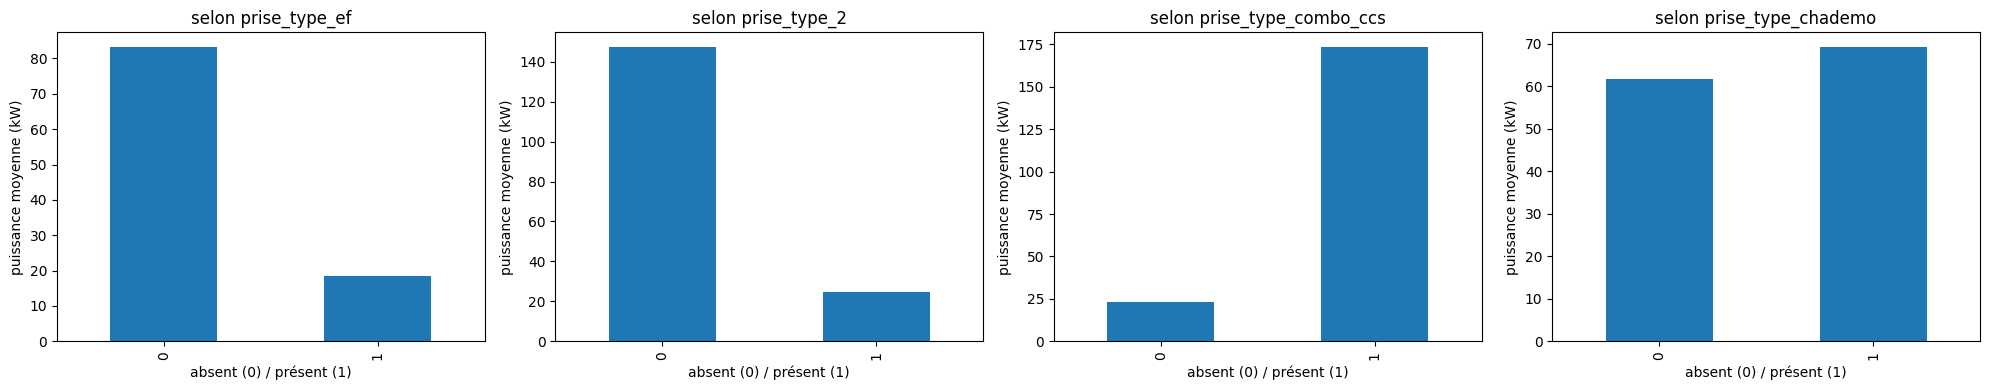

In [31]:
prises = ['prise_type_ef', 'prise_type_2', 'prise_type_combo_ccs',
          'prise_type_chademo']

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, col in zip(axes, prises):
    df.groupby(col)['puissance_nominale'].mean().plot.bar(ax=ax, title=f"selon {col}")
    ax.set_xlabel("absent (0) / présent (1)")
    ax.set_ylabel("puissance moyenne (kW)")
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Projet_IA/prises.png')
plt.show()

**Lecture :** la présence d'une prise Combo CCS ou CHAdeMO fait fortement **monter** la puissance moyenne (recharge rapide), tandis qu'une prise EF correspond à des puissances faibles comme la prise de type 2. Ces variables sont donc bien pertinentes pour la prédiction — on s'attend à les retrouver en tête de l'importance des variables (§8).

## 4. Prétraitement : encodage et normalisation

Les algorithmes ne savent traiter que des nombres. Il faut donc transformer chaque type de colonne :

- **Numériques** (`nbre_pdc`, longitude, latitude) → **`StandardScaler`** : on les met à la même échelle (moyenne 0, écart-type 1). C'est la **normalisation**. Elle est *indispensable* pour les modèles basés sur les distances (KNN) ou les coefficients (régression logistique), et sans effet négatif pour les arbres.
- **Booléens** (déjà en 0/1) → on les garde tels quels (`passthrough`).
- **Catégorielles** (`implantation_station`, `condition_acces`) → **`OneHotEncoder`** : on crée une colonne 0/1 par modalité (ex. « Parking public » devient une colonne valant 1 ou 0). `handle_unknown='ignore'` évite une erreur si une nouvelle modalité apparaît plus tard.

Tout cela est rassemblé dans un **`ColumnTransformer`**. On l'intègrera ensuite dans un **`Pipeline`** avec le modèle : ainsi, en sauvegardant le pipeline, on sauvegarde **aussi le prétraitement** — ce qui est exactement ce que demande l'énoncé pour le script final et la partie Web.

In [32]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocess = ColumnTransformer(transformers=[
    ('num',  StandardScaler(),                  num_features),   # colonnes numériques
    ('bool', 'passthrough',                     bool_features),  # colonnes 0/1
    ('cat',  OneHotEncoder(handle_unknown='ignore'), cat_features),  # colonnes texte
])
preprocess

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['nbre_pdc', 'long', 'lat']),
                                ('bool', 'passthrough',
                                 ['prise_type_ef', 'prise_type_2',
                                  'prise_type_combo_ccs', 'prise_type_chademo',
                                  'prise_type_autre', 'gratuit',
                                  'station_deux_roues']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['implantation_station', 'condition_acces'])])

## 5. Séparation train / test

On coupe les données en deux : **80 % pour l'entraînement**, **20 % pour le test**. Le modèle apprend sur le train et n'est évalué que sur le test, qu'il n'a jamais vu — c'est la seule façon de mesurer sa capacité à **généraliser**.

`stratify=y` garantit que les 4 classes gardent les mêmes proportions dans le train et le test (important avec des classes déséquilibrées).

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print("Train :", X_train.shape, "| Test :", X_test.shape)

Train : (113103, 12) | Test : (28276, 12)


## 6. Comparaison de plusieurs modèles

L'énoncé demande de **choisir** un algorithme : on en compare donc trois, représentatifs de familles différentes, pour justifier notre choix avec des chiffres.

| Modèle | Principe (résumé) | Forces / faiblesses |
|---|---|---|
| **Régression logistique** | trace des frontières *linéaires* entre les classes | simple et rapide, mais limitée si le lien n'est pas linéaire |
| **KNN (k plus proches voisins)** | classe une borne selon les *k* bornes les plus proches | intuitif, mais sensible à l'échelle et lent en prédiction |
| **Random Forest** | vote d'un grand nombre d'arbres de décision | puissant, gère les variables mélangées, peu de réglage |

Pour comparer équitablement, on utilise la **validation croisée** (`cross_val_score`) : on découpe le train en 3 plis, on entraîne sur 2 et on teste sur le 3e, en tournant. On obtient un score moyen plus fiable qu'un seul essai. On compare en **F1-macro** (adapté aux classes déséquilibrées).

*Remarque :* pour que la comparaison reste rapide, on l'effectue sur un échantillon de 15 000 bornes.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

# Echantillon pour accélérer la comparaison
X_ech = X_train.sample(min(15000, len(X_train)), random_state=0)
y_ech = y_train.loc[X_ech.index]

modeles = {
    'Régression logistique': LogisticRegression(max_iter=1000),
    'KNN':                   KNeighborsClassifier(n_neighbors=7),
    'Random Forest':         RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}

comparaison = []
for nom, modele in modeles.items():
    pipe = Pipeline([('preprocess', preprocess), ('model', modele)])
    scores = cross_val_score(pipe, X_ech, y_ech, cv=3, scoring='f1_macro', n_jobs=-1)
    comparaison.append({'modele': nom, 'f1_macro_moyen': scores.mean(), 'ecart_type': scores.std()})

comparaison = pd.DataFrame(comparaison).set_index('modele').sort_values('f1_macro_moyen', ascending=False)
print(comparaison.round(3))
comparaison['f1_macro_moyen'].plot.bar(title="Comparaison des modèles (F1-macro, validation croisée)")
plt.ylabel("F1-macro")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Projet_IA/comparaison_modeles.png')
plt.show()

### Conclusion de la comparaison

Le **Random Forest** obtient le meilleur F1-macro, devant le KNN, la régression logistique arrivant loin derrière. C'est logique : le lien entre les caractéristiques et la puissance n'est pas linéaire (d'où l'échec relatif de la régression logistique), et le random forest capture bien les interactions entre variables (ex. « Combo CCS ET nbre_pdc élevé »).

**On retient donc le Random Forest**, qu'on va maintenant optimiser.

### Principe du Random Forest (à mettre dans rapport)
Un **arbre de décision** pose une suite de questions binaires sur les variables (« prise Combo CCS ? », « nbre_pdc > 4 ? ») pour aboutir à une classe. Un arbre seul a tendance au **surapprentissage** (il colle trop aux données d'entraînement).

La **forêt aléatoire** construit des centaines d'arbres, chacun entraîné sur un tirage aléatoire des lignes (*bagging*) et un sous-ensemble aléatoire des variables. La prédiction finale est le **vote majoritaire** de tous les arbres. Cette diversité réduit le surapprentissage et rend le modèle robuste. Autre avantage : il fournit une **importance des variables** (§8) et ne nécessite pas de normalisation.

## 7. Optimisation des hyperparamètres avec GridSearchCV

Un modèle a des **hyperparamètres** (réglages fixés avant l'entraînement) qui influencent sa qualité. Pour le Random Forest, les principaux sont :
- `n_estimators` : le nombre d'arbres,
- `max_depth` : la profondeur maximale de chaque arbre,
- `min_samples_leaf` : le nombre minimal d'exemples par feuille (contre le surapprentissage).

**`GridSearchCV`** teste **toutes les combinaisons** de la grille proposée, chacune évaluée par validation croisée, et garde la meilleure. C'est exactement ce que demande l'énoncé.

⚠️ Cette cellule peut prendre **quelques minutes** (plusieurs combinaisons × 3 plis sur tout le train).

In [35]:
from sklearn.model_selection import GridSearchCV

pipe = Pipeline([
    ('preprocess', preprocess),
    ('model', RandomForestClassifier(random_state=42, n_jobs=-1)),
])

param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 20],
    'model__min_samples_leaf': [1, 5],
}

grid = GridSearchCV(pipe, param_grid, cv=3, scoring='f1_macro', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

print("\nMeilleurs hyperparamètres :", grid.best_params_)
print("Meilleur score CV (f1_macro) :", round(grid.best_score_, 3))
best_model = grid.best_estimator_

Fitting 3 folds for each of 8 candidates, totalling 24 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Meilleurs hyperparamètres : {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 100}
Meilleur score CV (f1_macro) : 0.916


## 8. Évaluation détaillée du modèle

On évalue le meilleur modèle sur le **jeu de test** (jamais utilisé jusqu'ici). On choisit plusieurs métriques complémentaires :

- **Accuracy** : proportion globale de bonnes prédictions. Simple, mais trompeuse si les classes sont déséquilibrées.
- **Précision** (par classe) : parmi les bornes prédites dans une classe, combien le sont vraiment.
- **Rappel** (par classe) : parmi les bornes réelles d'une classe, combien sont retrouvées.
- **F1-score** : moyenne harmonique précision/rappel — le bon résumé quand les classes sont déséquilibrées.
- **Matrice de confusion** : montre **quelles classes sont confondues** entre elles.

In [ ]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score)

y_pred = best_model.predict(X_test)

print("Accuracy :", round(accuracy_score(y_test, y_pred), 3))
print("\nRapport de classification :\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)
ConfusionMatrixDisplay(cm, display_labels=best_model.classes_).plot(
    xticks_rotation=45, cmap='Blues')
plt.title("Matrice de confusion")
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Projet_IA/matrice_confusion.png')
plt.show()

**Comment lire ces résultats :**
- Une **accuracy** élevée (~0.89) indique que le modèle se trompe rarement.
- Dans la **matrice de confusion**, les grandes valeurs sur la diagonale = bonnes prédictions. Les valeurs hors diagonale montrent les confusions : on observe surtout des confusions entre **classes voisines** (ex. « rapide » 22–50 kW confondue avec « accélérée » ou « ultra-rapide »), ce qui est normal pour des bornes proches de la frontière entre deux catégories.
- La classe la plus difficile est généralement `3_rapide`, car c'est une tranche étroite et moins fréquente.

### Importance des variables

Le Random Forest mesure combien chaque variable contribue aux décisions. Cela **confirme le choix des variables** : on s'attend à voir les types de prise (Combo CCS, CHAdeMO) et `nbre_pdc` en tête.

In [ ]:
# Importance des variables
noms = best_model.named_steps['preprocess'].get_feature_names_out()
importances = best_model.named_steps['model'].feature_importances_

imp = pd.Series(importances, index=noms).sort_values()
imp.tail(15).plot.barh(figsize=(8, 6), title="Variables les plus importantes")
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Projet_IA/importances.png')
plt.show()

**Lecture :** les variables les plus importantes correspondent bien à ce qu'on attendait (types de prise rapides, nombre de points de charge). Cela valide *a posteriori* notre sélection de variables au §3.

## 9. Sauvegarde du modèle (prétraitement inclus)

On enregistre le **pipeline complet** avec `joblib`. Comme il contient à la fois le prétraitement (scaler + one-hot) **et** le modèle entraîné, le script final n'aura qu'à le charger : aucun ré-entraînement, et le prétraitement est garanti identique à celui de l'apprentissage. C'est ce qu'exige l'énoncé pour la partie Web.

In [41]:
import joblib

joblib.dump(best_model, '/content/drive/MyDrive/Projet_IA/modele_puissance.pkl')
print("Modèle (pipeline complet : prétraitement + Random Forest) sauvegardé.")

Modèle (pipeline complet : prétraitement + Random Forest) sauvegardé.


## 10. Script de prédiction

Voici le script demandé : il **charge le modèle déjà entraîné** (il ne relance jamais l'apprentissage) et prédit la classe de puissance d'une borne décrite par ses caractéristiques.

On refait la même conversion des booléens en 0/1 qu'à l'entraînement. Le pipeline se charge ensuite tout seul du `StandardScaler` et du `OneHotEncoder`.

In [43]:
import joblib
import pandas as pd

# Chargement du modèle (UNE SEULE FOIS, au démarrage)
modele = joblib.load('/content/drive/MyDrive/Projet_IA/modele_puissance.pkl')

bool_features = ['prise_type_ef', 'prise_type_2', 'prise_type_combo_ccs',
                 'prise_type_chademo', 'prise_type_autre', 'gratuit', 'station_deux_roues']

def predire_puissance(borne):
    """Prend les caractéristiques d'une borne (dictionnaire) et renvoie sa classe de puissance."""
    X_new = pd.DataFrame([borne])
    for col in bool_features:
        X_new[col] = X_new[col].astype(str).str.lower().isin(['true', 'vrai']).astype(int)
    return modele.predict(X_new)[0]

# Exemple : une borne avec prises rapides en parking public
exemple = {
    'nbre_pdc': 4,
    'long': 2.3522,
    'lat': 48.8566,
    'prise_type_ef': 'false',
    'prise_type_2': 'true',
    'prise_type_combo_ccs': 'true',
    'prise_type_chademo': 'true',
    'prise_type_autre': 'false',
    'gratuit': 'false',
    'station_deux_roues': 'false',
    'implantation_station': 'Parking public',
    'condition_acces': 'Accès libre',
}
print("Classe de puissance prédite :", predire_puissance(exemple))

Classe de puissance prédite : 3_rapide
